# Task 3  SMS Spam Detection using Natural Language Processing

## 1. Dataset Loading and Exploration

This project focuses on detecting whether an SMS message is spam or legitimate (ham) using Natural Language Processing techniques.

The project will compare a traditional TF-IDF based machine learning model with an advanced Transformer based model.

In [7]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current working directory:
/content

Files and folders here:
['.config', 'spam_detection_distilbert', 'spam (1).csv', 'spam.csv', 'sample_data']


In [8]:
import pandas as pd

df = pd.read_csv(
    "spam.csv",
    encoding="latin-1"
)

print(df.shape)
print(df.columns)


(5572, 5)
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [9]:
df.shape

(5572, 5)

In [10]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [11]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [13]:
df = df[["v1", "v2"]]


In [14]:
df.columns = ["label", "message"]

In [15]:
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
print("Dataset shape:", df.shape)

Dataset shape: (5572, 2)


In [17]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
label      0
message    0
dtype: int64


In [18]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 403


In [19]:
print("\nClass distribution:")
print(df["label"].value_counts())


Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [21]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)
print("\nDuplicates remaining:", df.duplicated().sum())

Dataset shape after removing duplicates: (5169, 2)

Duplicates remaining: 0


In [22]:
df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [23]:
print(df["label_encoded"].value_counts())

label_encoded
0    4516
1     653
Name: count, dtype: int64


In [24]:
from sklearn.model_selection import train_test_split

# Features and target
X = df["message"]
y = df["label_encoded"]

# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (3618,)
Validation set: (775,)
Test set: (776,)


In [25]:
print("Training distribution:")
print(y_train.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Training distribution:
label_encoded
0    3161
1     457
Name: count, dtype: int64

Validation distribution:
label_encoded
0    677
1     98
Name: count, dtype: int64

Test distribution:
label_encoded
0    678
1     98
Name: count, dtype: int64


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    max_features=10000
)

# Learn vocabulary and IDF from training data only
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform validation and test data using the same vocabulary
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (3618, 8863)
Validation TF-IDF shape: (775, 8863)
Test TF-IDF shape: (776, 8863)


In [27]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_tfidf, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [28]:
y_val_pred = baseline_model.predict(X_val_tfidf)
y_test_pred = baseline_model.predict(X_test_tfidf)

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Baseline Validation Performance")
print("--------------------------------")

print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall   :", recall_score(y_val, y_val_pred))
print("F1 Score :", f1_score(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=["Ham", "Spam"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Baseline Validation Performance
--------------------------------
Accuracy : 0.9548387096774194
Precision: 0.9846153846153847
Recall   : 0.6530612244897959
F1 Score : 0.7852760736196319

Classification Report:
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       677
        Spam       0.98      0.65      0.79        98

    accuracy                           0.95       775
   macro avg       0.97      0.83      0.88       775
weighted avg       0.96      0.95      0.95       775

Confusion Matrix:
[[676   1]
 [ 34  64]]


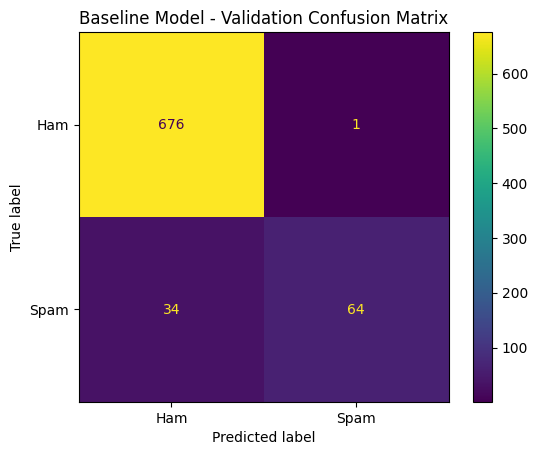

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    display_labels=["Ham", "Spam"]
)

plt.title("Baseline Model - Validation Confusion Matrix")
plt.show()

## Baseline NLP Model TF-IDF + Logistic Regression

A TF-IDF vectorizer was used to convert the SMS messages into numerical features, Unigrams and bigrams were included to capture both individual words and short phrases. The TF-IDF vectorizer was fitted only on the training data to prevent data leakage.

A Logistic Regression classifier was then trained using the TF-IDF features.

### Validation Results

| Metric | Score |
|---|---:|
| Accuracy | 0.9548 |
| Precision | 0.9846 |
| Recall | 0.6531 |
| F1 Score | 0.7853 |

The baseline achieved high precision, meaning that messages predicted as spam were usually genuinely spam. However, recall was lower at 65.31%, meaning that the model failed to detect 34 of the 98 spam messages in the validation set.
The main weakness of the baseline is therefore missed spam messages (false negatives). This provides a useful benchmark for evaluating the advanced NLP model.

### Confusion Matrix
The model produced 676 true negatives, 1 false positive, 34 false negatives,
and 64 true positives on the validation set.

In [31]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags if present
    text = re.sub(r"<.*?>", " ", text)

    # Replace multiple whitespace characters with a single space
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing whitespace
    text = text.strip()

    return text

In [32]:
df["clean_message"] = df["message"].apply(clean_text)

df[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling it's been 3 week's n...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me. ...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request 'melle melle (oru minnamin...
8,WINNER!! As a valued network customer you have...,winner!! as a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...,had your mobile 11 months or more? u r entitle...


In [33]:
print("Missing cleaned messages:", df["clean_message"].isnull().sum())

print(
    "Empty cleaned messages:",
    (df["clean_message"].str.strip() == "").sum()
)

Missing cleaned messages: 0
Empty cleaned messages: 0


In [34]:
df[df["label"] == "spam"][["message", "clean_message"]].head(10)

,message,clean_message
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling it's been 3 week's n...
8,WINNER!! As a valued network customer you have...,winner!! as a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...,had your mobile 11 months or more? u r entitle...
11,"SIX chances to win CASH! From 100 to 20,000 po...","six chances to win cash! from 100 to 20,000 po..."
12,URGENT! You have won a 1 week FREE membership ...,urgent! you have won a 1 week free membership ...
15,"XXXMobileMovieClub: To use your credit, click ...","xxxmobilemovieclub: to use your credit, click ..."
19,England v Macedonia - dont miss the goals/team...,england v macedonia - dont miss the goals/team...
34,Thanks for your subscription to Ringtone UK yo...,thanks for your subscription to ringtone uk yo...
42,07732584351 - Rodger Burns - MSG = We tried to...,07732584351 - rodger burns - msg = we tried to...


In [35]:
import transformers
import datasets
import torch

print("Transformers version:", transformers.__version__)
print("Datasets version:", datasets.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Transformers version: 5.16.1
Datasets version: 4.8.5
PyTorch version: 2.11.0+cu128
CUDA available: True


In [36]:
import sys
import torch
import transformers
import datasets

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Datasets: 4.8.5
CUDA available: True
GPU: Tesla T4


In [37]:
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam (2).csv


In [38]:
import pandas as pd

df = pd.read_csv(
    "spam.csv",
    encoding="latin-1"
)

print(df.shape)
print(df.columns)

(5572, 5)
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [39]:
df = df[["v1", "v2"]]

df.columns = ["label", "message"]

df = df.drop_duplicates().reset_index(drop=True)

df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("Dataset shape:", df.shape)
print(df["label_encoded"].value_counts())

Dataset shape: (5169, 3)
label_encoded
0    4516
1     653
Name: count, dtype: int64


In [40]:
from sklearn.model_selection import train_test_split

# Text and target
X = df["message"]
y = df["label_encoded"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (3618,)
Validation set: (775,)
Test set: (776,)


In [41]:
print("Training distribution:")
print(y_train.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Training distribution:
label_encoded
0    3161
1     457
Name: count, dtype: int64

Validation distribution:
label_encoded
0    677
1     98
Name: count, dtype: int64

Test distribution:
label_encoded
0    678
1     98
Name: count, dtype: int64


In [42]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

print("Tokenizer loaded successfully!")

Tokenizer loaded successfully!


In [43]:
sample_message = X_train.iloc[0]

print("Original message:")
print(sample_message)

print("\nTokenized:")
print(tokenizer.tokenize(sample_message))

print("\nToken IDs:")
print(tokenizer(sample_message)["input_ids"][:20])

Original message:
Why tired what special there you had

Tokenized:
['why', 'tired', 'what', 'special', 'there', 'you', 'had']

Token IDs:
[101, 2339, 5458, 2054, 2569, 2045, 2017, 2018, 102]


In [44]:
max_length = 128

In [45]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

val_dataset = Dataset.from_dict({
    "text": X_val.tolist(),
    "label": y_val.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

print("Training:", train_dataset)
print("Validation:", val_dataset)
print("Test:", test_dataset)

Training: Dataset({
    features: ['text', 'label'],
    num_rows: 3618
})
Validation: Dataset({
    features: ['text', 'label'],
    num_rows: 775
})
Test: Dataset({
    features: ['text', 'label'],
    num_rows: 776
})


In [46]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization complete!")

Map:   0%|          | 0/3618 [00:00<?, ? examples/s]

Map:   0%|          | 0/775 [00:00<?, ? examples/s]

Map:   0%|          | 0/776 [00:00<?, ? examples/s]

Tokenization complete!


In [47]:
print(train_tokenized[0])

{'text': 'Why tired what special there you had', 'label': 0, 'input_ids': [101, 2339, 5458, 2054, 2569, 2045, 2017, 2018, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [48]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    id2label={
        0: "HAM",
        1: "SPAM"
    },
    label2id={
        "HAM": 0,
        "SPAM": 1
    }
)

print("DistilBERT model loaded successfully!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully!


In [49]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./spam_detection_distilbert",

    num_train_epochs=3,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="epoch",

    fp16=True,

    report_to="none",

    seed=42
)

print("Training configuration created successfully!")

Training configuration created successfully!


In [50]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Convert model outputs into predicted classes
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0)
    }

print("Metrics function created successfully!")

Metrics function created successfully!


In [51]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


In [52]:
print("Training examples:", len(train_tokenized))
print("Validation examples:", len(val_tokenized))
print("GPU available:", torch.cuda.is_available())

Training examples: 3618
Validation examples: 775
GPU available: True


In [53]:
import time

start_time = time.time()

training_result = trainer.train()

training_time = time.time() - start_time

print(f"\nTraining completed in {training_time / 60:.2f} minutes.")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.091598,0.039120,0.989677,0.989130,0.928571,0.957895
2,0.027447,0.035424,0.989677,0.978723,0.938776,0.958333
3,0.013876,0.041666,0.990968,0.978947,0.948980,0.963731


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed in 0.92 minutes.


In [54]:
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions from the best DistilBERT model
val_results = trainer.predict(val_tokenized)

# Convert logits to predicted classes
y_val_distilbert = np.argmax(val_results.predictions, axis=-1)

print("DistilBERT Validation Classification Report")
print("--------------------------------------------")

print(classification_report(
    y_val,
    y_val_distilbert,
    target_names=["Ham", "Spam"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_distilbert))

DistilBERT Validation Classification Report
--------------------------------------------
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       677
        Spam       0.98      0.95      0.96        98

    accuracy                           0.99       775
   macro avg       0.99      0.97      0.98       775
weighted avg       0.99      0.99      0.99       775

Confusion Matrix:
[[675   2]
 [  5  93]]


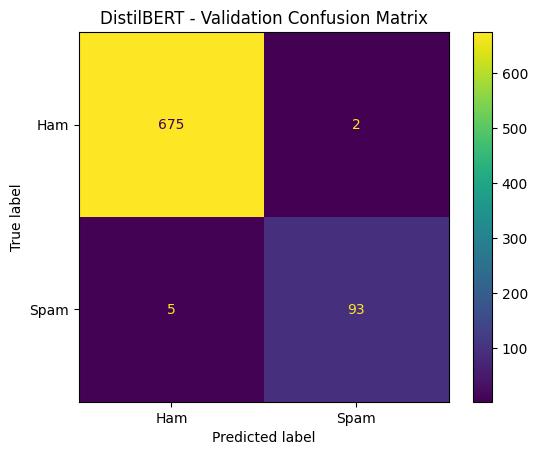

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_distilbert,
    display_labels=["Ham", "Spam"]
)

plt.title("DistilBERT - Validation Confusion Matrix")
plt.show()

In [56]:
# Evaluate the best DistilBERT model on the untouched test set
test_results = trainer.predict(test_tokenized)

# Convert logits to predicted classes
y_test_distilbert = np.argmax(test_results.predictions, axis=-1)

print("DistilBERT Test Classification Report")
print("--------------------------------------")

print(classification_report(
    y_test,
    y_test_distilbert,
    target_names=["Ham", "Spam"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_distilbert))

DistilBERT Test Classification Report
--------------------------------------
              precision    recall  f1-score   support

         Ham       1.00      0.99      0.99       678
        Spam       0.96      0.97      0.96        98

    accuracy                           0.99       776
   macro avg       0.98      0.98      0.98       776
weighted avg       0.99      0.99      0.99       776

Confusion Matrix:
[[674   4]
 [  3  95]]


In [57]:
distilbert_test_accuracy = accuracy_score(y_test, y_test_distilbert)
distilbert_test_precision = precision_score(y_test, y_test_distilbert)
distilbert_test_recall = recall_score(y_test, y_test_distilbert)
distilbert_test_f1 = f1_score(y_test, y_test_distilbert)

print("Accuracy :", distilbert_test_accuracy)
print("Precision:", distilbert_test_precision)
print("Recall   :", distilbert_test_recall)
print("F1 Score :", distilbert_test_f1)

Accuracy : 0.990979381443299
Precision: 0.9595959595959596
Recall   : 0.9693877551020408
F1 Score : 0.9644670050761421


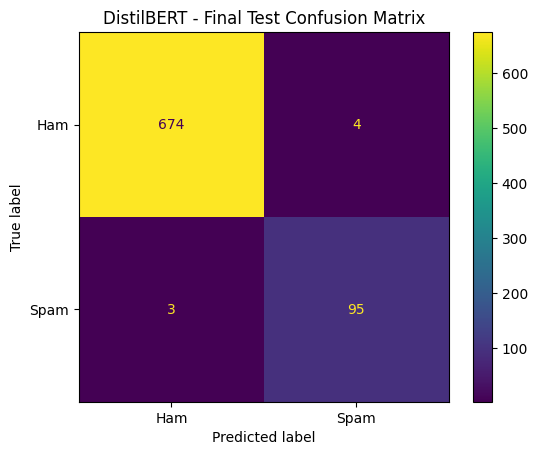

In [58]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_distilbert,
    display_labels=["Ham", "Spam"]
)

plt.title("DistilBERT - Final Test Confusion Matrix")
plt.show()

In [59]:
# Baseline predictions on the untouched test set
y_test_baseline = baseline_model.predict(X_test_tfidf)

print("Baseline Test Classification Report")
print("-----------------------------------")

print(classification_report(
    y_test,
    y_test_baseline,
    target_names=["Ham", "Spam"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_baseline))

Baseline Test Classification Report
-----------------------------------
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       678
        Spam       1.00      0.69      0.82        98

    accuracy                           0.96       776
   macro avg       0.98      0.85      0.90       776
weighted avg       0.96      0.96      0.96       776

Confusion Matrix:
[[678   0]
 [ 30  68]]


In [60]:
baseline_test_accuracy = accuracy_score(y_test, y_test_baseline)
baseline_test_precision = precision_score(y_test, y_test_baseline)
baseline_test_recall = recall_score(y_test, y_test_baseline)
baseline_test_f1 = f1_score(y_test, y_test_baseline)

print("Accuracy :", baseline_test_accuracy)
print("Precision:", baseline_test_precision)
print("Recall   :", baseline_test_recall)
print("F1 Score :", baseline_test_f1)

Accuracy : 0.961340206185567
Precision: 1.0
Recall   : 0.6938775510204082
F1 Score : 0.8192771084337349


## Model Comparison Baseline vs Advanced Model

Both models were evaluated on the same untouched test set containing 776 SMS
messages to ensure a fair comparison.

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| TF-IDF + Logistic Regression | 0.9613 | 1.0000 | 0.6939 | 0.8193 |
| **DistilBERT** | **0.9910** | **0.9691** | **0.9592** | **0.9641** |

### Interpretation

The DistilBERT model substantially outperformed the traditional TF-IDF +
Logistic Regression baseline. Accuracy increased from 96.13% to 99.10%, while
F1 score increased from 81.93% to 96.41%.

The largest improvement was in recall, which increased from 69.39% to 95.92%.
The baseline missed 30 of the 98 spam messages, whereas DistilBERT missed only 4.

The baseline achieved 100% precision on the test set, meaning it produced no
false positive spam predictions. However, this came at the cost of missing a
large number of spam messages. DistilBERT reduced precision slightly to 96.91%
but detected substantially more spam messages.

Given the objective of detecting spam effectively, DistilBERT was selected as
the final model because it provides a much better balance between precision,
recall, and F1 score.

In [61]:
import time

start_time = time.time()

y_test_baseline = baseline_model.predict(X_test_tfidf)

baseline_inference_time = time.time() - start_time

print(f"Baseline inference time: {baseline_inference_time:.4f} seconds")
print(f"Average per message: {(baseline_inference_time / len(X_test)) * 1000:.4f} ms")

Baseline inference time: 0.0023 seconds
Average per message: 0.0030 ms


In [62]:
start_time = time.time()

test_results = trainer.predict(test_tokenized)

distilbert_inference_time = time.time() - start_time

print(f"DistilBERT inference time: {distilbert_inference_time:.4f} seconds")
print(f"Average per message: {(distilbert_inference_time / len(X_test)) * 1000:.4f} ms")

DistilBERT inference time: 0.9285 seconds
Average per message: 1.1965 ms


## Model Comparison: Performance, Speed and Complexity

| Model | Accuracy | Precision | Recall | F1 Score | Inference Time | Complexity |
|---|---:|---:|---:|---:|---:|---|
| TF-IDF + Logistic Regression | 0.9613 | 1.0000 | 0.6939 | 0.8193 | 0.0023 s | Low |
| **DistilBERT** | **0.9910** | 0.9691 | **0.9592** | **0.9641** | 0.9285 s | High |

Both models were evaluated on the same 776-message test set.

The TF-IDF + Logistic Regression model is substantially faster and has lower
computational complexity. However, it has significantly lower recall and F1
score.

DistilBERT requires greater computational resources and has slower inference,
but it provides substantially better spam detection performance. Recall
increased from 69.39% to 95.92%, while F1 increased from 81.93% to 96.41%.

The small reduction in precision from 100% to 96.91% is an acceptable
trade-off because DistilBERT detects substantially more actual spam messages.

Based on the balance between detection performance and the project's objective,
DistilBERT was selected as the final model.

In [64]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [65]:
import os

project_dir = "/content/drive/MyDrive/Spam_Detection_Project"
model_dir = os.path.join(project_dir, "spam_distilbert_final")

os.makedirs(model_dir, exist_ok=True)

print("Project folder:", project_dir)
print("Model folder:", model_dir)

Project folder: /content/drive/MyDrive/Spam_Detection_Project
Model folder: /content/drive/MyDrive/Spam_Detection_Project/spam_distilbert_final


In [66]:
trainer.save_model(model_dir)
tokenizer.save_pretrained(model_dir)

print("DistilBERT model and tokenizer saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model and tokenizer saved successfully!


In [67]:
import os

print("Saved files:")

for file in os.listdir(model_dir):
    print(file)

Saved files:
config.json
model.safetensors
training_args.bin
tokenizer_config.json
tokenizer.json
